In [1]:
import librosa
import soundfile as sf
import os
import math
import numpy as np
import glob

In [15]:
input_folder = r"/home/pom/code/Pom-Savitree/maestro-v3.0.0-mp3/maestro-v3.0.0-mp3/2018"
output_dir = r"/home/pom/code/Pom-Savitree/maestro-v3.0.0-mp3/Output"

In [46]:
class AudioPreprocessingPipeline:
    def __init__(self, output_dir, slice_duration=20, n_mels=128, n_fft=2048, hop_length=512):
        self.output_dir = output_dir
        self.slice_duration = slice_duration
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
        
        # create folder if not existed
        if not os.path.exists(self.output_dir):
            os.makedirs(self.output_dir)
            
    def split_audio(self, file_path):
        #getiing filename
        file_basename = os.path.splitext(os.path.basename(file_path))[0]
        total_duration = librosa.get_duration(path=file_path)
        total_slices = math.ceil(total_duration/self.slice_duration)
        
        for i in range(total_slices):
            start_time = i * self.slice_duration
            remaining_time = total_duration - start_time
            current_duration = min(remaining_time, self.slice_duration)
            
            #skipping slicing if less than 2 sec
            if current_duration < 2:
                continue
            
            y, sr = librosa.load(file_path, sr=None, offset=start_time, duration=current_duration)
            mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=self.n_mels, n_fft=self.n_fft, hop_length=self.hop_length)

            # Convert amplitude to log scale (decibels / dB)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            
            #saving Mel-Spectrogram Matrix as a NumPy binary file (.npy)
            base_filename = f"{file_basename}_Split_Part_{i+1}"
            npy_path = os.path.join(self.output_dir, f"{base_filename}.npy")
            np.save(npy_path, mel_spec_db)
            
            #save wav
            # output_filename = f"Split_Part_{i+1}.wav"
            # output_path = os.path.join(output_dir, output_filename)
            #sf.write(output_path, y, sr)

    def run(self, input_folder):
        #Loop each files and tranform to Mel-Spectrogram
        mp3_files = glob.glob(os.path.join(input_folder, "*.mp3")) #searching for mp3 files
        
        for index, current_file in enumerate(mp3_files):
            print(f"[{index+1}/{len(mp3_files)}] Processing: {os.path.basename(current_file)}")
            self.split_audio(current_file)
            
    def run_single(self, filename):
        self.split_audio(filename)

In [ ]:
pipeline = AudioPreprocessingPipeline(
    output_dir='./output',
    slice_duration=20,
    n_mels=128,
    hop_length=512
)

In [53]:
pipeline.run_single('/home/pom/code/emilegeagea/sheetify/MIDI-Unprocessed_Chamber2_MID--AUDIO_09_R3_2018_wav--1.mp3')

/home/pom/.pyenv/versions/sheetify/lib/python3.10/site-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


In [54]:
arr = np.load("output/MIDI-Unprocessed_Chamber2_MID--AUDIO_09_R3_2018_wav--1_Split_Part_1.npy")
arr

array([[-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ],
       [-68.322754, -77.65611 , -57.9888  , ..., -48.845768, -52.351048,
        -46.754272],
       [-55.911896, -65.245255, -45.577946, ..., -36.434914, -39.940193,
        -34.343422],
       ...,
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ]], shape=(512, 1876), dtype=float32)

In [55]:
arr.shape

(512, 1876)

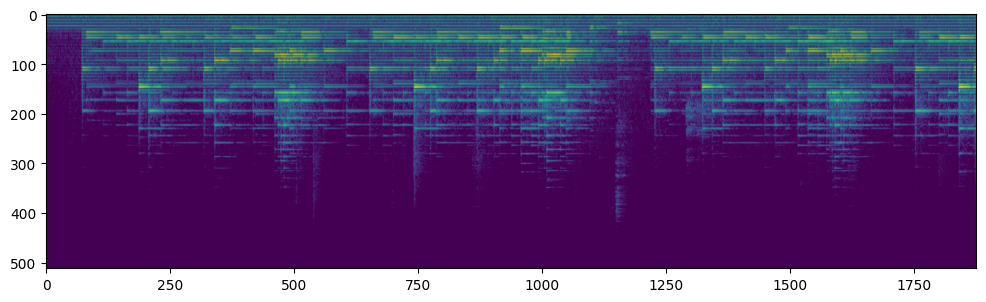

In [56]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 10))
plt.imshow(arr)